IMPORT LIBIRARY

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import emlearn

IMPORT DATASET

In [ ]:
dataset = pd.read_csv(file_path_dataset)
Glucose_array = dataset["Glucose_level"].values
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Glucose_array, test_size = 0.3, random_state = 0)

22


MULTIPLE LINEAR REGRESSION

=== KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH LINEAR REGRESSION ===
MAE = 14.726805906144252
RMSE = 18.70125049799766
R2 = 0.03856788874432393
MARD = 12.48037644540208


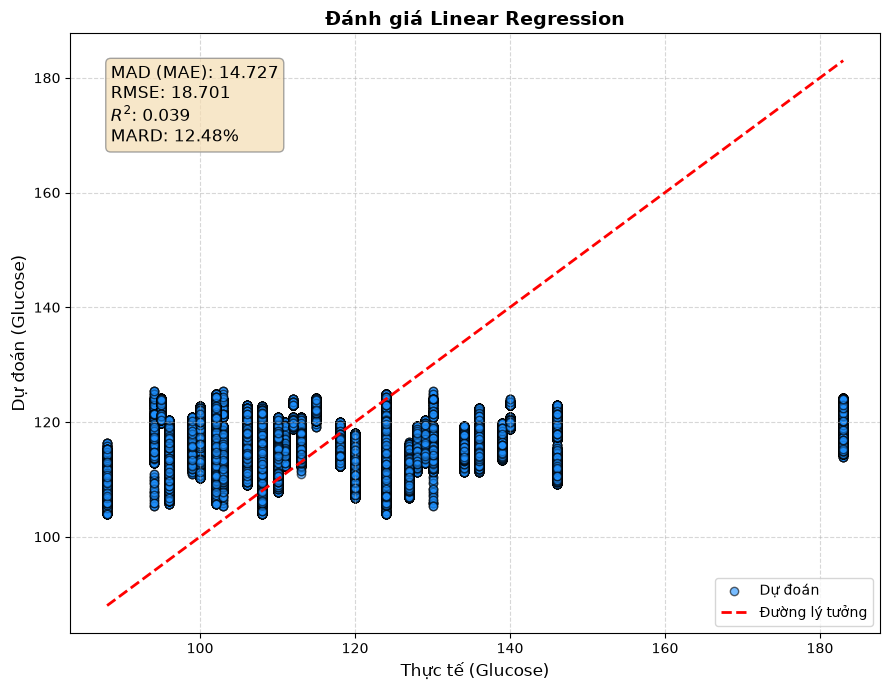

In [3]:
# Training the Simple Linear Regression model on the Training set
from sklearn.linear_model import LinearRegression
regressor_linear = LinearRegression()
regressor_linear.fit(X_train, y_train)

# Predicting the Test set results
y_pred = regressor_linear.predict(X_test)

# Evaluating the model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

MAE_linear_regression = mean_absolute_error(y_test, y_pred)
MSE_linear_regression = mean_squared_error(y_test, y_pred)
r2_linear_regression = r2_score(y_test, y_pred)
rmse_linear_regression = np.sqrt(MSE_linear_regression)
MARD_linear_regression = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-8))) * 100

print("=== KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH LINEAR REGRESSION ===")
print("MAE =", MAE_linear_regression)
print("RMSE =", rmse_linear_regression)
print("R2 =", r2_linear_regression)
print("MARD =", MARD_linear_regression)
print("==================================================")

# Vẽ biểu đồ Scatter Kèm chỉ số
plt.figure(figsize=(9, 7))
plt.scatter(y_test, y_pred, alpha=0.6, color='dodgerblue', edgecolor='k', label='Dự đoán')
min_val = min(np.min(y_test), np.min(y_pred))
max_val = max(np.max(y_test), np.max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Đường lý tưởng')

textstr = '\n'.join((
    f'MAD (MAE): {MAE_linear_regression:.3f}',
    f'RMSE: {rmse_linear_regression:.3f}',
    f'$R^2$: {r2_linear_regression:.3f}',
    f'MARD: {MARD_linear_regression:.2f}%'
))
props = dict(boxstyle='round', facecolor='wheat', alpha=0.7, edgecolor='gray')
plt.gca().text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=12,
        verticalalignment='top', bbox=props)

plt.xlabel("Thực tế (Glucose)", fontsize=12)
plt.ylabel("Dự đoán (Glucose)", fontsize=12)
plt.title("Đánh giá Linear Regression", fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


DECISION TREE INTUITION

=== KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH DECISION TREE ===
MAD (MAE) : 12.2585
RMSE      : 15.8891
R2 Score  : 0.3060
MARD      : 10.45 %


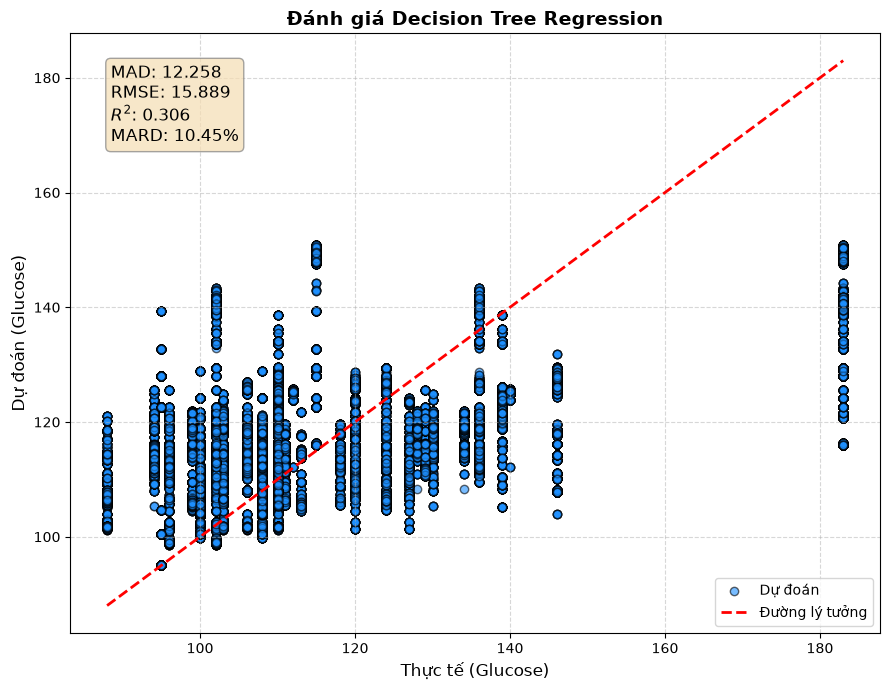

In [4]:
# Training the Decision Tree Regression model on the Training set
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

regressor_decision_tree = DecisionTreeRegressor(random_state = 0)
regressor_decision_tree.fit(X_train, y_train)

y_pred_dt = regressor_decision_tree.predict(X_test)

# Tính toán các chỉ số
mad_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)
mard_dt = np.mean(np.abs((y_test - y_pred_dt) / (y_test + 1e-8))) * 100 

print("=== KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH DECISION TREE ===")
print(f"MAD (MAE) : {mad_dt:.4f}")
print(f"RMSE      : {rmse_dt:.4f}")
print(f"R2 Score  : {r2_dt:.4f}")
print(f"MARD      : {mard_dt:.2f} %")
print("==============================================")

# Vẽ biểu đồ Scatter Kèm chỉ số
plt.figure(figsize=(9, 7))
plt.scatter(y_test, y_pred_dt, alpha=0.6, color='dodgerblue', edgecolor='k', label='Dự đoán')
min_val = min(np.min(y_test), np.min(y_pred_dt))
max_val = max(np.max(y_test), np.max(y_pred_dt))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Đường lý tưởng')

textstr = '\n'.join((
    f'MAD: {mad_dt:.3f}',
    f'RMSE: {rmse_dt:.3f}',
    f'$R^2$: {r2_dt:.3f}',
    f'MARD: {mard_dt:.2f}%'
))
props = dict(boxstyle='round', facecolor='wheat', alpha=0.7, edgecolor='gray')
plt.gca().text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=12,
        verticalalignment='top', bbox=props)

plt.xlabel("Thực tế (Glucose)", fontsize=12)
plt.ylabel("Dự đoán (Glucose)", fontsize=12)
plt.title("Đánh giá Decision Tree Regression", fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


RANDOM FOREST

=== KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH RANDOM FOREST ===
MAD (MAE) : 12.2590
RMSE      : 15.8892
R2 Score  : 0.3060
MARD      : 10.45 %


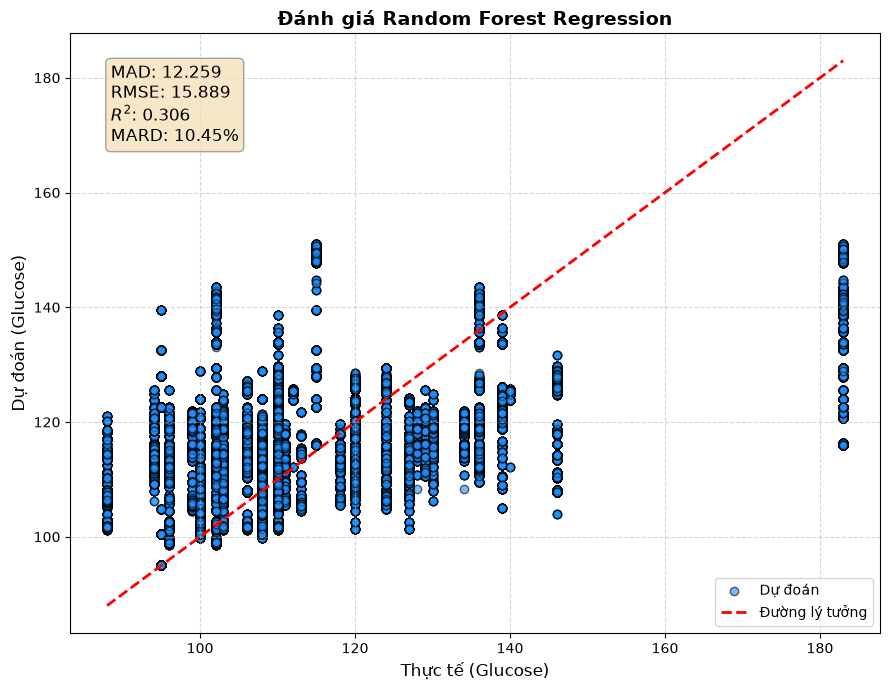

In [7]:
# Training the Random Forest Regression model on the Training set
from sklearn.ensemble import RandomForestRegressor
regressor_random_forest = RandomForestRegressor(n_estimators = 100, random_state = 0)
regressor_random_forest.fit(X_train, y_train)

y_pred_rf = regressor_random_forest.predict(X_test)

# Tính toán các chỉ số
mad_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
mard_rf = np.mean(np.abs((y_test - y_pred_rf) / (y_test + 1e-8))) * 100 

print("=== KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH RANDOM FOREST ===")
print(f"MAD (MAE) : {mad_rf:.4f}")
print(f"RMSE      : {rmse_rf:.4f}")
print(f"R2 Score  : {r2_rf:.4f}")
print(f"MARD      : {mard_rf:.2f} %")
print("==============================================")

# Vẽ biểu đồ Scatter Kèm chỉ số
plt.figure(figsize=(9, 7))
plt.scatter(y_test, y_pred_rf, alpha=0.6, color='dodgerblue', edgecolor='k', label='Dự đoán')
min_val = min(np.min(y_test), np.min(y_pred_rf))
max_val = max(np.max(y_test), np.max(y_pred_rf))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Đường lý tưởng') 
textstr = '\n'.join((
    f'MAD: {mad_rf:.3f}',
    f'RMSE: {rmse_rf:.3f}',
    f'$R^2$: {r2_rf:.3f}',
    f'MARD: {mard_rf:.2f}%'
))
props = dict(boxstyle='round', facecolor='wheat', alpha=0.7, edgecolor='gray')
plt.gca().text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=12,
        verticalalignment='top', bbox=props)

plt.xlabel("Thực tế (Glucose)", fontsize=12)
plt.ylabel("Dự đoán (Glucose)", fontsize=12)
plt.title("Đánh giá Random Forest Regression", fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

XGBoost

=== KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH XGBOOST ===
MAD (MAE) : 11.6510
RMSE      : 15.0752
R2 Score  : 0.3753
MARD      : 9.92 %


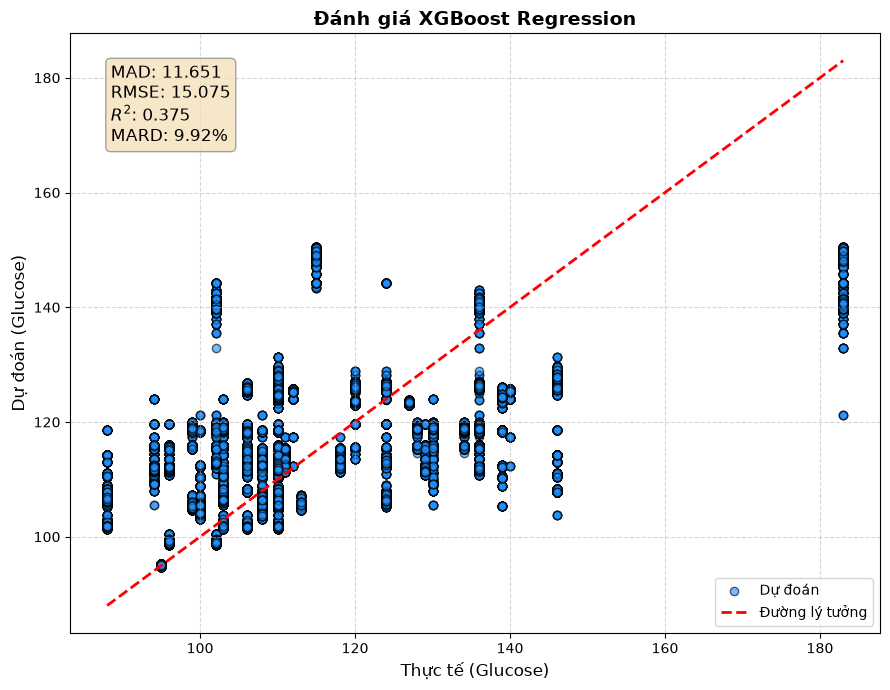

In [10]:
from xgboost import XGBRegressor
regressor = XGBRegressor()
regressor.fit(X_train, y_train)

y_pred_xgb = regressor.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mad_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)
mard_xgb = np.mean(np.abs((y_test - y_pred_xgb) / (y_test + 1e-8))) * 100 

print("=== KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH XGBOOST ===")
print(f"MAD (MAE) : {mad_xgb:.4f}")
print(f"RMSE      : {rmse_xgb:.4f}")
print(f"R2 Score  : {r2_xgb:.4f}")
print(f"MARD      : {mard_xgb:.2f} %")
print("==============================================")

plt.figure(figsize=(9, 7))
plt.scatter(y_test, y_pred_xgb, alpha=0.6, color='dodgerblue', edgecolor='k', label='Dự đoán')
min_val = min(np.min(y_test), np.min(y_pred_xgb))
max_val = max(np.max(y_test), np.max(y_pred_xgb))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Đường lý tưởng') 
textstr = '\n'.join((
    f'MAD: {mad_xgb:.3f}',
    f'RMSE: {rmse_xgb:.3f}',
    f'$R^2$: {r2_xgb:.3f}',
    f'MARD: {mard_xgb:.2f}%'
))
props = dict(boxstyle='round', facecolor='wheat', alpha=0.7, edgecolor='gray')
plt.gca().text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=12,
        verticalalignment='top', bbox=props)

plt.xlabel("Thực tế (Glucose)", fontsize=12)
plt.ylabel("Dự đoán (Glucose)", fontsize=12)
plt.title("Đánh giá XGBoost Regression", fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
